# Late Fusion: CNN (image) + Random Forest (metadata)

**Input.** Combined `fusion_df` has `image_name, patient_id, target, p_cnn, p_rf`. 
These are the base models' predictions on the validation set (1,235 images, 25 melanomas, 85 patients). 
The fusion models are **trained on this table only**. 
`fusion_test_df` has the same columns for the test set and is used once, at the end.

**Fusion methods**

| # | Method | Formula | Learned parameters |
|---|---|---|---|
| 1 | Simple average | $(p_{cnn} + p_{rf})/2$ | 0 |
| 2 | Rank average | mean of each score's percentile within the *validation* score distribution | 0 |
| 3 | Weighted logit average | $w\cdot\text{logit}(p_{cnn}) + (1-w)\cdot\text{logit}(p_{rf})$ | 1 ($w$) |
| 4 | Logistic-regression stacking | $\sigma(a + b\cdot\text{logit}(p_{cnn}) + c\cdot\text{logit}(p_{rf}))$ | 3 |

**Evaluation plan**
1. **Model selection on validation.** Use repeated, patient-grouped, stratified 5-fold CV on `fusion_df`.
   Each fold's fusion model is fit on 4/5 of the patients and scored on the other 1/5. That gives honest
   out-of-fold (OOF) predictions for every method, plus CNN-only and RF-only as reference points.
2. **Thresholds.** Each fold picks its decision threshold on its *training* part (the highest threshold
   that keeps sensitivity ≥ `TARGET_SENS`) and applies it to the held-out part. Sensitivity and
   specificity are therefore out-of-sample too.
3. **Choose the winner on validation CV (primary metric: PR-AUC).** Refit every method on the full
   `fusion_df` and report all of them on the test set once. The winner is fixed *before* looking at test,
   so the test numbers stay unbiased.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)

SEED        = 42
N_SPLITS    = 5      # ~5 melanomas per held-out fold
N_REPEATS   = 20     # repeat CV with different shuffles: one split of 25 positives is too noisy
TARGET_SENS = 0.80   # operating point: catch at least 80% of melanomas
N_BOOT      = 2000   # bootstrap resamples for test-set confidence intervals
EPS         = 1e-4   # clip probabilities before logit (RF can output exactly 0 or 1)

# Plot colours: base models in grey, the four fusion methods in fixed categorical order
COLORS = {"CNN only": "#8a8984", "RF only": "#c3c2b7",
          "1. Simple avg": "#2a78d6", "2. Rank avg": "#eb6834",
          "3. Weighted logit": "#1baf7a", "4. LR stacking": "#eda100"}

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Explore `fusion_df`

In [30]:
BASE = '/content/drive/MyDrive/Melanoma Project'

fusion_df = pd.read_csv(f"{BASE}/validation_predictions_combined.csv")
fusion_df.rename(columns={"prob_resnet_mlp": "resnet_probability", "prob_rf": "rf_probability"}, inplace=True)
fusion_df.drop(columns="prob_lr", inplace=True)

fusion_test_df = pd.read_csv(f"{BASE}/test_predictions_combined.csv")
fusion_test_df.rename(columns={"prob_resnet_mlp": "resnet_probability", "prob_rf": "rf_probability"}, inplace=True)
fusion_test_df.drop(columns="prob_lr", inplace=True)

print(fusion_df)
print(fusion_test_df)

        image_name  patient_id  target  rf_probability  resnet_probability
0     ISIC_0082348  IP_7684360       0        0.433097            0.009063
1     ISIC_0109869  IP_8171635       0        0.654909            0.006542
2     ISIC_0179191  IP_5304634       0        0.331404            0.012864
3     ISIC_0192419  IP_3253955       0        0.406178            0.009407
4     ISIC_0196399  IP_9054996       0        0.643859            0.389542
...            ...         ...     ...             ...                 ...
1230  ISIC_9967383  IP_7887363       1        0.507447            0.356030
1231  ISIC_9969263  IP_7684360       0        0.433097            0.065558
1232  ISIC_9971202  IP_9711347       0        0.464732            0.076200
1233  ISIC_9985141  IP_7950112       0        0.331404            0.147905
1234  ISIC_9987485  IP_9433384       0        0.424801            0.019429

[1235 rows x 5 columns]
        image_name  patient_id  target  rf_probability  resnet_probability


In [4]:
REQUIRED = ["image_name", "patient_id", "target", "resnet_probability", "rf_probability"]
assert set(REQUIRED) <= set(fusion_df.columns), f"fusion_df needs columns {REQUIRED}"
assert fusion_df[REQUIRED].notna().all().all(), "missing values in fusion_df"
assert fusion_df["image_name"].is_unique, "duplicate images in fusion_df"
fusion_df = fusion_df.reset_index(drop=True)

print(f"Validation rows: {len(fusion_df)} | melanomas: {fusion_df['target'].sum()} "
      f"| patients: {fusion_df['patient_id'].nunique()}")
fusion_df[["resnet_probability", "rf_probability"]].describe().T

Validation rows: 1235 | melanomas: 25 | patients: 85


,count,mean,std,min,25%,50%,75%,max
resnet_probability,1235.0,0.130098,0.158661,0.000023,0.017579,0.070501,0.181261,0.947282
rf_probability,1235.0,0.471767,0.103039,0.323461,0.406178,0.433097,0.511935,0.741290


### Correlation Check
The two models score on different scales. A CNN trained with class weights pushes benign cases to
~0.1–0.2, not ~0.02, and the RF has its own scale. That is why methods 2–4 do not average the raw
probabilities. The correlation shows how much the models **disagree**. Low correlation means more to
gain from fusion.

Correlation (Spearman) between resnet_probability and rf_probability: 0.211


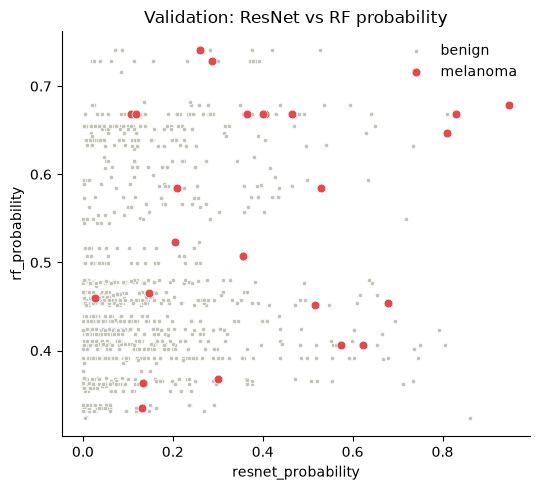

In [5]:
print("Correlation (Spearman) between resnet_probability and rf_probability:",
      round(fusion_df[["resnet_probability", "rf_probability"]].corr(method="spearman").iloc[0, 1], 3))

fig, ax = plt.subplots(figsize=(5.5, 5))
for t, c, lab, s in [(0, "#c3c2b7", "benign", 10), (1, "#e34948", "melanoma", 40)]:
    d = fusion_df[fusion_df["target"] == t]
    ax.scatter(d["resnet_probability"], d["rf_probability"], s=s, c=c, label=lab, edgecolors="white", linewidths=0.5)
ax.set_xlabel("resnet_probability"); ax.set_ylabel("rf_probability"); ax.set_title("Validation: ResNet vs RF probability")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 1. The four fusion models
Every method has the same `fit(df)` / `predict(df)` interface, so the CV loop and the test evaluation
can treat them identically. `predict` returns a **score**: higher means more likely melanoma. Only
method 4 returns a calibrated probability.

In [6]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), EPS, 1 - EPS)
    return np.log(p / (1 - p))


class BaseOnly:
    # Reference point: one base model's own probability, no fusion.
    def __init__(self, col): self.col = col
    def fit(self, df): return self
    def predict(self, df): return df[self.col].to_numpy(dtype=float)


class SimpleAverage:
    # Method 1: (resnet_probability + rf_probability) / 2. Nothing to learn.
    def fit(self, df): return self
    def predict(self, df):
        return (df["resnet_probability"].to_numpy(float) + df["rf_probability"].to_numpy(float)) / 2


class RankAverage:
    # Method 2: average of percentiles.
    # fit() stores the training score distribution of each model. predict() maps a new score to
    # "fraction of training scores below it" (an empirical CDF). New data is never ranked against
    # itself, so test scores do not depend on the rest of the test set, and a threshold chosen on
    # validation carries over.
    def fit(self, df):
        self.ref = {c: np.sort(df[c].to_numpy(float)) for c in ["resnet_probability", "rf_probability"]}
        return self
    def _pct(self, col, x):
        r = self.ref[col]
        # midpoint of left/right insertion -> ties get the average rank
        return (np.searchsorted(r, x, "left") + np.searchsorted(r, x, "right")) / (2 * len(r))
    def predict(self, df):
        return (self._pct("resnet_probability", df["resnet_probability"].to_numpy(float)) +
                self._pct("rf_probability",  df["rf_probability"].to_numpy(float))) / 2


class WeightedLogit:
    # Method 3: w * logit(p_cnn) + (1 - w) * logit(p_rf), with w chosen on the training data.
    # w = 1 -> CNN only, w = 0 -> RF only. The chosen w is the "how much do we trust the image" number.
    # w is picked by ROC-AUC because AUC is smooth and stable with very few positives.
    # (PR-AUC on ~20 positives jumps around too much to tune on.)
    def __init__(self, grid=np.round(np.linspace(0, 1, 21), 2)): self.grid = grid
    def _score(self, df, w):
        return w * logit(df["resnet_probability"]) + (1 - w) * logit(df["rf_probability"])
    def fit(self, df):
        y = df["target"].to_numpy()
        self.curve_ = np.array([roc_auc_score(y, self._score(df, w)) for w in self.grid])
        best = np.flatnonzero(self.curve_ >= self.curve_.max() - 1e-12)
        self.w_ = float(self.grid[best].mean())   # middle of any tie plateau, not an arbitrary edge
        return self
    def predict(self, df): return self._score(df, self.w_)


class LRStacking:
    # Method 4: logistic regression meta-learner on the two logits.
    #   P(melanoma) = sigmoid(a + b * logit(p_cnn) + c * logit(p_rf))
    # No class_weight, so the output stays a calibrated probability at the real prevalence.
    # L2 penalty (C=1) shrinks b and c a little, which keeps them stable with ~25 positives.
    def __init__(self, C=1.0): self.C = C
    def _X(self, df): return np.column_stack([logit(df["resnet_probability"]), logit(df["rf_probability"])])
    def fit(self, df):
        self.model_ = LogisticRegression(C=self.C, max_iter=1000).fit(self._X(df), df["target"])
        return self
    def predict(self, df): return self.model_.predict_proba(self._X(df))[:, 1]
    @property
    def coefs_(self):
        return dict(intercept=self.model_.intercept_[0],
                    b_cnn=self.model_.coef_[0, 0], c_rf=self.model_.coef_[0, 1])


def make_models():
    # Fresh, unfitted instances, so no state leaks between CV folds.
    return {"CNN only": BaseOnly("resnet_probability"), "RF only": BaseOnly("rf_probability"),
            "1. Simple avg": SimpleAverage(), "2. Rank avg": RankAverage(),
            "3. Weighted logit": WeightedLogit(), "4. LR stacking": LRStacking()}

FUSION_NAMES = ["1. Simple avg", "2. Rank avg", "3. Weighted logit", "4. LR stacking"]

## 2. Metric helpers
* **ROC-AUC**: chance that a random melanoma scores higher than a random benign lesion. It ignores prevalence.
* **PR-AUC (average precision)**: how clean the top of the ranking is. This is the more honest metric at
  ~2% prevalence, where random guessing scores ≈ 0.02 (not 0.5).
* **Sensitivity / specificity** at a threshold chosen on *training* data to reach `TARGET_SENS`.
* **Patient-level bootstrap**: resample *patients* (not images) with replacement and recompute the
  metrics. This gives confidence intervals that reflect how few melanomas and patients there are.
  Every method is scored on the same resamples, so differences between methods are paired.

In [7]:
def threshold_for_sensitivity(y, s, target=TARGET_SENS):
    # Highest threshold whose sensitivity on (y, s) is >= target.
    # A higher threshold means fewer false positives, so take the highest one that still catches
    # enough melanomas.
    pos = np.sort(s[y == 1])[::-1]                 # positive scores, high -> low
    k = int(np.ceil(target * len(pos)))            # need at least k positives at or above threshold
    return pos[k - 1]

def patient_bootstrap(df, scores, n_boot=N_BOOT, seed=SEED):
    # Resample patients with replacement and recompute AUCs for every method on the same resamples.
    # Returns a dict of arrays: model -> (n_boot, 2) array of [roc_auc, pr_auc].
    rng = np.random.default_rng(seed)
    pids = df["patient_id"].to_numpy()
    uniq = np.unique(pids)
    rows_of = {p: np.flatnonzero(pids == p) for p in uniq}
    y = df["target"].to_numpy()
    out = {m: [] for m in scores}
    for _ in range(n_boot):
        idx = np.concatenate([rows_of[p] for p in rng.choice(uniq, len(uniq), replace=True)])
        if y[idx].min() == y[idx].max():
            continue                       # resample without both classes -> AUC undefined
        for m, s in scores.items():
            out[m].append((roc_auc_score(y[idx], s[idx]), average_precision_score(y[idx], s[idx])))
    return {m: np.array(v) for m, v in out.items()}


def threshold_metrics(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return dict(sens=tp / (tp + fn), spec=tn / (tn + fp),
                ppv=tp / (tp + fp) if tp + fp else np.nan, tp=tp, fp=fp, fn=fn, tn=tn)

## 3. Repeated patient-grouped cross-validation on the validation set
`StratifiedGroupKFold` keeps every image of a patient in the same fold, which stops leakage through
look-alike lesions on one person. It also spreads the melanomas evenly across folds.

Repeating the CV with different shuffles measures how much the *fitted* methods (3, 4) depend on the
split. It says nothing about sampling uncertainty: methods 1 and 2 give the same OOF scores on every
repeat, so their SD across repeats is ~0. Section 3a therefore also bootstraps patients on the OOF
predictions to get real confidence intervals.

Within each repeat, OOF predictions from the 5 folds are **pooled** before computing AUCs. With only
~5 positives per fold, per-fold AUCs would be very noisy. Pooling is safe for methods 1, 2 and 4.
For method 3, the score scale shifts slightly when $w$ differs between folds, so its pooled AUC is a
little pessimistic, if anything.

In [8]:
y_all, groups = fusion_df["target"].to_numpy(), fusion_df["patient_id"].to_numpy()
cv_rows, w_per_fold, coef_per_fold = [], [], []
oof_first = None    # OOF scores of repeat 0, kept for plotting curves

for rep in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + rep)
    oof = {name: np.zeros(len(fusion_df)) for name in make_models()}
    oof_pred = {name: np.zeros(len(fusion_df), dtype=int) for name in make_models()}

    for tr_idx, va_idx in sgkf.split(fusion_df, y_all, groups):
        tr, va = fusion_df.iloc[tr_idx], fusion_df.iloc[va_idx]
        for name, model in make_models().items():
            model.fit(tr)
            thr = threshold_for_sensitivity(tr["target"].to_numpy(), model.predict(tr))
            s_va = model.predict(va)
            oof[name][va_idx] = s_va
            oof_pred[name][va_idx] = (s_va >= thr).astype(int)
            if name == "3. Weighted logit": w_per_fold.append(model.w_)
            if name == "4. LR stacking":    coef_per_fold.append(model.coefs_)

    for name in oof:
        cv_rows.append(dict(repeat=rep, model=name,
                            roc_auc=roc_auc_score(y_all, oof[name]),
                            pr_auc=average_precision_score(y_all, oof[name]),
                            **threshold_metrics(y_all, oof_pred[name])))
    if rep == 0:
        oof_first = oof

cv_df = pd.DataFrame(cv_rows)
print(f"Done: {N_REPEATS} repeats x {N_SPLITS} folds")

Done: 20 repeats x 5 folds


### 3a. Cross-validated results
`mean` / `std` = across CV repeats (split variability). `ci95` = patient-bootstrap 95% CI of the OOF
metric (sampling uncertainty, the one to report). `P(beats CNN)` = share of bootstrap resamples where
the method beats CNN-only.

In [9]:
order = list(make_models())
cv_summary = (cv_df.groupby("model")[["roc_auc", "pr_auc", "sens", "spec", "ppv"]]
              .agg(["mean", "std"]).reindex(order))

# Uncertainty: patient-level bootstrap of the OOF predictions (CV repeat 0).
# Every method is scored on the same resamples, so "P(beats CNN)" is a paired comparison.
val_boot = patient_bootstrap(fusion_df, oof_first)
for metric, j in [("roc_auc", 0), ("pr_auc", 1)]:
    cv_summary[(metric, "ci95")] = [f"[{np.percentile(val_boot[m][:, j], 2.5):.3f}, "
                                    f"{np.percentile(val_boot[m][:, j], 97.5):.3f}]" for m in order]
    cv_summary[("P(beats CNN)", metric)] = [(val_boot[m][:, j] > val_boot["CNN only"][:, j]).mean()
                                            for m in order]
cv_summary = cv_summary[["roc_auc", "pr_auc", "sens", "spec", "ppv", "P(beats CNN)"]]
cv_summary.round(3)

roc_auc                        pr_auc         \
                     mean    std            ci95   mean    std   
model                                                            
CNN only            0.850  0.000  [0.763, 0.916]  0.182  0.000   
RF only             0.704  0.000  [0.544, 0.838]  0.070  0.000   
1. Simple avg       0.845  0.000  [0.743, 0.920]  0.212  0.000   
2. Rank avg         0.827  0.003  [0.714, 0.907]  0.169  0.007   
3. Weighted logit   0.846  0.015  [0.772, 0.925]  0.204  0.013   
4. LR stacking      0.851  0.005  [0.757, 0.917]  0.198  0.005   

                                    sens          spec           ppv         \
                             ci95   mean    std   mean    std   mean    std   
model                                                                         
CNN only           [0.052, 0.357]  0.784  0.030  0.723  0.012  0.055  0.002   
RF only            [0.030, 0.131]  0.768  0.016  0.417  0.026  0.027  0.001   
1. Simple avg      [0.061, 0.387]  0.794  0.020  0.740  0.012  0.059  0.002   
2. Rank avg        [0.058, 0.309]  0.796  0.041  0.681  0.026  0.049  0.003   
3. Weighted logit  [0.063, 0.384]  0.752  0.025  0.768  0.011  0.063  0.003   
4. LR stacking     [0.056, 0.363]  0.758  0.027  0.770  0.010  0.064  0.003   

                  P(beats CNN)         
                       roc_auc pr_auc  
model                                  
CNN only                 0.000  0.000  
RF only                  0.024  0.041  
1. Simple avg            0.416  0.815  
2. Rank avg              0.242  0.386  
3. Weighted logit        0.690  0.820  
4. LR stacking           0.450  0.610

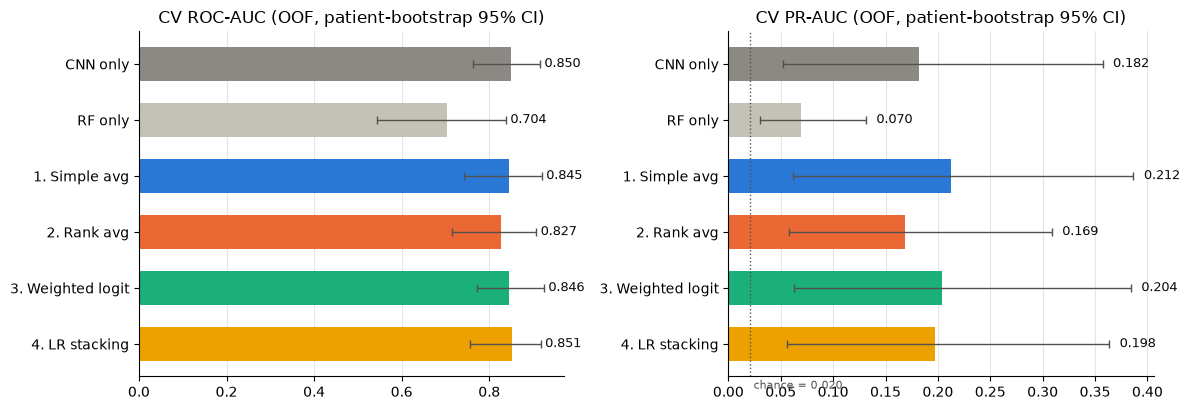

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric, title in [(axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")]:
    m = cv_summary[(metric, "mean")]
    j = 0 if metric == "roc_auc" else 1
    lo = np.array([np.percentile(val_boot[k][:, j], 2.5) for k in order[::-1]])
    hi = np.array([np.percentile(val_boot[k][:, j], 97.5) for k in order[::-1]])
    mv = m[order[::-1]].to_numpy()
    ax.barh(order[::-1], mv, xerr=[np.clip(mv - lo, 0, None), np.clip(hi - mv, 0, None)], height=0.6,
            color=[COLORS[k] for k in order[::-1]], error_kw=dict(ecolor="#52514e", lw=1, capsize=3))
    for i, k in enumerate(order[::-1]):
        ax.text(max(hi[i], m[k]) + 0.01, i, f"{m[k]:.3f}", va="center", fontsize=9, color="#0b0b0b")
    if metric == "pr_auc":
        prev = y_all.mean()
        ax.axvline(prev, color="#52514e", ls=":", lw=1)
        ax.text(prev, -0.8, f" chance = {prev:.3f}", fontsize=8, color="#52514e")
    ax.set_title(f"CV {title} (OOF, patient-bootstrap 95% CI)")
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="x", color="#e6e5e0", lw=0.8)
    ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

### 3b. What did the learned methods learn?
* **Method 3**: the distribution of $w$ across folds shows how much the image is trusted relative to
  metadata. If it is stable around one value, the trade-off is real. If it is spread from 0 to 1, the
  data cannot tell.
* **Method 4**: $b$ and $c$ are the log-odds weights on each model. Because both inputs are logits,
  $b / (b + c)$ is comparable to $w$.

Method 3, w (CNN weight) across 100 folds: median 0.50, IQR [0.40, 0.55]


,intercept,b_cnn,c_rf,cnn_share
mean,-2.463,0.905,0.874,0.511
std,0.129,0.088,0.153,0.057
min,-2.779,0.726,0.351,0.368
max,-2.201,1.122,1.281,0.741


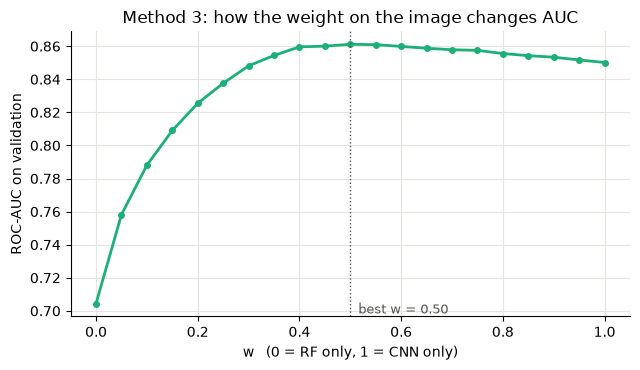

In [11]:
w_arr = np.array(w_per_fold)
coef_df = pd.DataFrame(coef_per_fold)
coef_df["cnn_share"] = coef_df["b_cnn"] / (coef_df["b_cnn"] + coef_df["c_rf"])

print(f"Method 3, w (CNN weight) across {len(w_arr)} folds: "
      f"median {np.median(w_arr):.2f}, IQR [{np.percentile(w_arr,25):.2f}, {np.percentile(w_arr,75):.2f}]")
display(coef_df.describe().loc[["mean", "std", "min", "max"]].round(3))

# AUC as a function of w on the FULL validation set: the shape of the trade-off
wl_full = WeightedLogit().fit(fusion_df)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(wl_full.grid, wl_full.curve_, color=COLORS["3. Weighted logit"], lw=2, marker="o", ms=4)
ax.axvline(wl_full.w_, color="#52514e", ls=":", lw=1)
ax.text(wl_full.w_, ax.get_ylim()[0], f"  best w = {wl_full.w_:.2f}", fontsize=9, color="#52514e", va="bottom")
ax.set_xlabel("w   (0 = RF only, 1 = CNN only)"); ax.set_ylabel("ROC-AUC on validation")
ax.set_title("Method 3: how the weight on the image changes AUC")
ax.spines[["top", "right"]].set_visible(False); ax.grid(color="#e6e5e0", lw=0.8)
plt.tight_layout(); plt.show()

### 3c. ROC and precision-recall curves (OOF predictions, CV repeat 0)

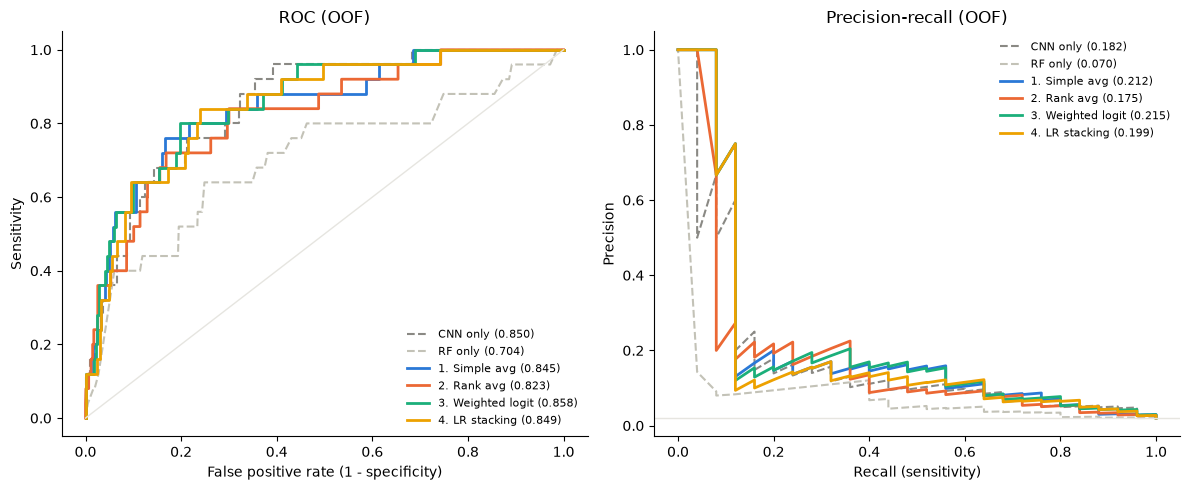

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name in order:
    s = oof_first[name]
    base = name in ("CNN only", "RF only")
    kw = dict(color=COLORS[name], lw=1.5 if base else 2, ls="--" if base else "-")
    fpr, tpr, _ = roc_curve(y_all, s)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_all, s):.3f})", **kw)
    prec, rec, _ = precision_recall_curve(y_all, s)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_all, s):.3f})", **kw)
axes[0].plot([0, 1], [0, 1], color="#e6e5e0", lw=1)
axes[0].set(xlabel="False positive rate (1 - specificity)", ylabel="Sensitivity", title="ROC (OOF)")
axes[1].axhline(y_all.mean(), color="#e6e5e0", lw=1)
axes[1].set(xlabel="Recall (sensitivity)", ylabel="Precision", title="Precision-recall (OOF)")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="lower right" if ax is axes[0] else "upper right")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Pick the winner on validation
**Candidates and baselines.** Only the two *learned* fusion methods compete for the winner. The two
fixed rules are kept as **baselines**: they are reported in every table for comparison, but they are
not deployable candidates. This was the plan from the start; an earlier version of the code let the
baselines compete by mistake.

| Role | Methods | Why |
|---|---|---|
| Candidates | 3. Weighted logit, 4. LR stacking | Learn from data how much to trust each model, on a common (log-odds) scale |
| Baselines | 1. Simple average, 2. Rank average | Fixed 50/50 rules that learn nothing; they show what fusion gives *without* learning |

Simple average has a second problem: it averages two probabilities that are on **different scales**
(section 0), so its result depends on how each base model happens to be calibrated, not on how
informative it is. On the validation set, its ROC-AUC swung from 0.762 to 0.845 when the RF was
retrained, while weighted logit stayed at 0.847 → 0.846. A method whose behaviour depends on an
arbitrary property of its inputs is a poor choice to deploy.

**Selection rule (unchanged), applied to the candidates:**
1. For each metric (ROC-AUC and PR-AUC), find the best candidate by CV mean.
2. A candidate is *eligible* if its gap to that best is at most **one paired-bootstrap standard error**
   on **both** metrics.
3. Among eligible candidates, take the **simplest** (fewest learned parameters: method 3 before 4).
4. If none is eligible on both metrics, take the best average rank across the two metrics.

The rule and the candidate list are fixed **before** the test set is used. Never change the winner
because of test results: that would make the test score optimistic (Varma & Simon, 2006).

In [13]:
CANDIDATES = ["3. Weighted logit", "4. LR stacking"]    # learned fusion methods, simple -> complex
BASELINES  = ["1. Simple avg", "2. Rank avg"]           # fixed rules, reported for comparison only
METRICS = {"roc_auc": 0, "pr_auc": 1}                   # column index inside val_boot arrays
best_by_metric = {m: cv_summary.loc[CANDIDATES, (m, "mean")].idxmax() for m in METRICS}

rows = []
for name in CANDIDATES + BASELINES:
    row, within_both = {"model": name, "role": "candidate" if name in CANDIDATES else "baseline"}, True
    for metric, j in METRICS.items():
        top = best_by_metric[metric]
        gap = cv_summary.loc[top, (metric, "mean")] - cv_summary.loc[name, (metric, "mean")]
        se = (val_boot[top][:, j] - val_boot[name][:, j]).std(ddof=1)   # paired bootstrap SE
        within = gap <= se
        row.update({f"{metric} mean": cv_summary.loc[name, (metric, "mean")],
                    f"{metric} gap to best": gap, f"{metric} SE": se, f"{metric} within 1 SE": within})
        within_both &= within
    row["spec @80% sens"] = cv_summary.loc[name, ("spec", "mean")]
    row["eligible"] = within_both and name in CANDIDATES
    rows.append(row)
selection = pd.DataFrame(rows).set_index("model")

eligible_models = list(selection.index[selection["eligible"]])
if eligible_models:
    chosen = eligible_models[0]                 # simplest eligible candidate
    reason = "simplest candidate within 1 SE of the best candidate on both ROC-AUC and PR-AUC"
else:
    avg_rank = sum(cv_summary.loc[CANDIDATES, (m, "mean")].rank(ascending=False) for m in METRICS)
    chosen = avg_rank.idxmin()
    reason = "no candidate within 1 SE on both metrics -> best average rank"

print("Best candidate per metric:", best_by_metric)
display(selection.round(3))
print(f"\nWINNER: {chosen}   ({reason})")

# Context only: is any baseline clearly better than the winner? (It cannot be chosen, but say so if it is.)
for b in BASELINES:
    better = [m for m, j in METRICS.items()
              if cv_summary.loc[b, (m, "mean")] - cv_summary.loc[chosen, (m, "mean")]
              > (val_boot[b][:, j] - val_boot[chosen][:, j]).std(ddof=1)]
    print(f"Baseline {b}: " + (f"better than the winner by more than 1 SE on {better}" if better
                                 else "not clearly better than the winner"))

# Does the winner beat the image model alone? Paired bootstrap on the same patient resamples.
print(f"\n{chosen} vs CNN only (validation OOF, patient bootstrap):")
for metric, j in METRICS.items():
    d = val_boot[chosen][:, j] - val_boot["CNN only"][:, j]
    print(f"  {metric:<8} {cv_summary.loc[chosen, (metric, 'mean')]:.3f} vs "
          f"{cv_summary.loc['CNN only', (metric, 'mean')]:.3f} | difference 95% CI "
          f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}] | P(fusion better) = {(d > 0).mean():.2f}")

Best candidate per metric: {'roc_auc': '4. LR stacking', 'pr_auc': '3. Weighted logit'}


,role,roc_auc mean,roc_auc gap to best,roc_auc SE,roc_auc within 1 SE,pr_auc mean,pr_auc gap to best,pr_auc SE,pr_auc within 1 SE,spec @80% sens,eligible
model,,,,,,,,,,,
3. Weighted logit,candidate,0.846,0.006,0.009,True,0.204,0.000,0.000,True,0.768,True
4. LR stacking,candidate,0.851,0.000,0.000,True,0.198,0.006,0.010,True,0.770,True
1. Simple avg,baseline,0.845,0.006,0.014,True,0.212,-0.009,0.009,True,0.740,False
2. Rank avg,baseline,0.827,0.024,0.028,True,0.169,0.035,0.034,False,0.681,False



WINNER: 3. Weighted logit   (simplest candidate within 1 SE of the best candidate on both ROC-AUC and PR-AUC)
Baseline 1. Simple avg: not clearly better than the winner
Baseline 2. Rank avg: not clearly better than the winner

3. Weighted logit vs CNN only (validation OOF, patient bootstrap):
  roc_auc  0.846 vs 0.850 | difference 95% CI [-0.021, +0.035] | P(fusion better) = 0.69
  pr_auc   0.204 vs 0.182 | difference 95% CI [-0.026, +0.082] | P(fusion better) = 0.82


## 5. Fit on the full validation set (final models)
Each method is refit on **all** of `fusion_df`. The operating threshold for each method comes from the
**pooled OOF scores** of CV repeat 0, not from the in-sample fit. This matters most for method 4: its
in-sample probabilities are slightly over-confident, which would pick a threshold that misses more
melanomas on new data.

*(For methods 1–2, OOF and in-sample scores are identical apart from method 2's reference
distribution, so this makes little difference. For methods 3–4, their scale changes slightly between
folds and the full fit, so the threshold is approximate. That is acceptable, because the AUCs do not
depend on it.)*

In [14]:
final_models = {name: model.fit(fusion_df) for name, model in make_models().items()}
final_thr = {name: threshold_for_sensitivity(y_all, final_models[name].predict(fusion_df))
             if name in ("CNN only", "RF only", "1. Simple avg", "2. Rank avg")
             else threshold_for_sensitivity(y_all, oof_first[name])
             for name in final_models}

print(f"Method 3 final w = {final_models['3. Weighted logit'].w_:.2f}")
print("Method 4 final coefficients:",
      {k: round(v, 3) for k, v in final_models['4. LR stacking'].coefs_.items()})
pd.Series(final_thr, name=f"threshold for sens >= {TARGET_SENS}").round(4)

Method 3 final w = 0.50
Method 4 final coefficients: {'intercept': np.float64(-2.46), 'b_cnn': np.float64(0.91), 'c_rf': np.float64(0.908)}


CNN only             0.1476
RF only              0.4514
1. Simple avg        0.3640
2. Rank avg          0.6198
3. Weighted logit   -0.6615
4. LR stacking       0.0213
Name: threshold for sens >= 0.8, dtype: float64

## 6. Test set: run **once**, after the winner is fixed
Requires `fusion_test_df` with the same columns. The test predictions **must** come from the same
CNN and RF that produced the validation predictions (trained on the 5,630-image training split).
If the base models are retrained on train + validation, their score scales shift and the fusion
weights no longer apply.

Reported for every method: ROC-AUC and PR-AUC with **patient-level bootstrap** 95% CIs (resampling
patients, not images, because images from one patient are correlated), sensitivity, specificity and
PPV at the validation threshold, and a **paired bootstrap of ΔAUC vs CNN only**. If the ΔAUC CI
excludes 0, fusion beats the image alone.

In [15]:
assert set(REQUIRED) <= set(fusion_test_df.columns), f"fusion_test_df needs columns {REQUIRED}"
test = fusion_test_df.reset_index(drop=True)
y_te = test["target"].to_numpy()
te_scores = {name: m.predict(test) for name, m in final_models.items()}
boot = patient_bootstrap(test, te_scores)

rows = []
for name, s in te_scores.items():
    b = boot[name]
    d = b - boot["CNN only"]          # paired: same resamples
    rows.append(dict(
        model=name,
        roc_auc=roc_auc_score(y_te, s),
        roc_ci=f"[{np.percentile(b[:,0],2.5):.3f}, {np.percentile(b[:,0],97.5):.3f}]",
        pr_auc=average_precision_score(y_te, s),
        pr_ci=f"[{np.percentile(b[:,1],2.5):.3f}, {np.percentile(b[:,1],97.5):.3f}]",
        d_roc_vs_cnn_ci=f"[{np.percentile(d[:,0],2.5):+.3f}, {np.percentile(d[:,0],97.5):+.3f}]",
        d_pr_vs_cnn_ci=f"[{np.percentile(d[:,1],2.5):+.3f}, {np.percentile(d[:,1],97.5):+.3f}]",
        **threshold_metrics(y_te, (s >= final_thr[name]).astype(int))))
test_results = pd.DataFrame(rows).set_index("model")
print(f"Test rows: {len(test)} | melanomas: {y_te.sum()} | patients: {test['patient_id'].nunique()}")
print(f"Pre-registered winner (chosen on validation): {chosen}")
display(test_results.round(3))

Test rows: 1988 | melanomas: 31 | patients: 106
Pre-registered winner (chosen on validation): 3. Weighted logit


,roc_auc,roc_ci,pr_auc,pr_ci,d_roc_vs_cnn_ci,d_pr_vs_cnn_ci,sens,spec,ppv,tp,fp,fn,tn
model,,,,,,,,,,,,,
CNN only,0.844,"[0.745, 0.922]",0.133,"[0.059, 0.309]","[+0.000, +0.000]","[+0.000, +0.000]",0.774,0.786,0.054,24,419,7,1538
RF only,0.685,"[0.561, 0.797]",0.034,"[0.017, 0.080]","[-0.283, -0.038]","[-0.261, -0.024]",0.742,0.562,0.026,23,858,8,1099
1. Simple avg,0.817,"[0.710, 0.909]",0.137,"[0.057, 0.340]","[-0.082, +0.019]","[-0.035, +0.068]",0.581,0.852,0.058,18,290,13,1667
2. Rank avg,0.818,"[0.720, 0.900]",0.116,"[0.057, 0.259]","[-0.082, +0.026]","[-0.113, +0.050]",0.677,0.766,0.044,21,458,10,1499
3. Weighted logit,0.842,"[0.743, 0.922]",0.157,"[0.061, 0.347]","[-0.017, +0.015]","[-0.013, +0.063]",0.613,0.856,0.063,19,281,12,1676
4. LR stacking,0.842,"[0.743, 0.922]",0.157,"[0.061, 0.347]","[-0.017, +0.015]","[-0.013, +0.063]",0.645,0.840,0.060,20,314,11,1643


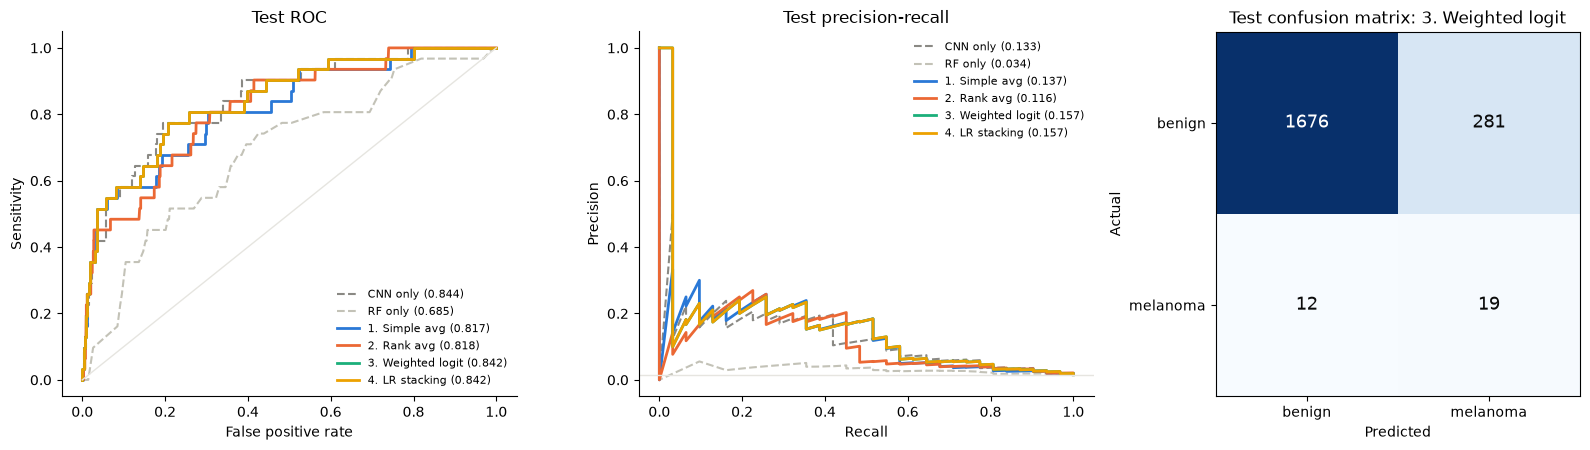

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw=dict(width_ratios=[1, 1, 0.8]))
for name in order:
    s = te_scores[name]
    base = name in ("CNN only", "RF only")
    kw = dict(color=COLORS[name], lw=1.5 if base else 2, ls="--" if base else "-")
    fpr, tpr, _ = roc_curve(y_te, s)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_te, s):.3f})", **kw)
    prec, rec, _ = precision_recall_curve(y_te, s)
    axes[1].plot(rec, prec, label=f"{name} ({average_precision_score(y_te, s):.3f})", **kw)
axes[0].plot([0, 1], [0, 1], color="#e6e5e0", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="Sensitivity", title="Test ROC")
axes[1].axhline(y_te.mean(), color="#e6e5e0", lw=1)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Test precision-recall")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")

cm = confusion_matrix(y_te, (te_scores[chosen] >= final_thr[chosen]).astype(int))
axes[2].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axes[2].text(j, i, f"{v}", ha="center", va="center", fontsize=13,
                    color="white" if v > cm.max() / 2 else "#0b0b0b")
axes[2].set(xticks=[0, 1], yticks=[0, 1], xticklabels=["benign", "melanoma"],
            yticklabels=["benign", "melanoma"], xlabel="Predicted", ylabel="Actual",
            title=f"Test confusion matrix: {chosen}")
for ax in axes[:2]:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Final comparison: validation CV vs test
One table to put in the report. Use the **validation CV** columns to justify the choice of fusion
method, and the **test** columns to report how well it generalises. Read the test columns with their
confidence intervals: on ~35 test melanomas, differences of a few points of AUC are usually inside
the noise.

In [17]:
final_table = pd.DataFrame({
    "CV ROC-AUC": cv_summary[("roc_auc", "mean")].round(3),
    "CV ROC 95% CI": cv_summary[("roc_auc", "ci95")],
    "CV PR-AUC":  cv_summary[("pr_auc", "mean")].round(3),
    "CV PR 95% CI": cv_summary[("pr_auc", "ci95")],
    "CV sens":    cv_summary[("sens", "mean")].round(3),
    "CV spec":    cv_summary[("spec", "mean")].round(3),
    "CV P(PR-AUC > CNN)": cv_summary[("P(beats CNN)", "pr_auc")].round(2),
})
final_table = final_table.join(test_results[["roc_auc", "roc_ci", "pr_auc", "pr_ci",
                                                "d_pr_vs_cnn_ci", "sens", "spec"]]
                                .round(3).add_prefix("Test "))
final_table["chosen"] = ["<-- winner" if m == chosen else "" for m in final_table.index]
final_table.insert(0, "role", ["winner" if m == chosen else "candidate" if m in CANDIDATES
                             else "baseline" if m in BASELINES else "single model" for m in final_table.index])
final_table

,role,CV ROC-AUC,CV ROC 95% CI,CV PR-AUC,CV PR 95% CI,CV sens,CV spec,CV P(PR-AUC > CNN),Test roc_auc,Test roc_ci,Test pr_auc,Test pr_ci,Test d_pr_vs_cnn_ci,Test sens,Test spec,chosen
model,,,,,,,,,,,,,,,,
CNN only,single model,0.850,"[0.763, 0.916]",0.182,"[0.052, 0.357]",0.784,0.723,0.00,0.844,"[0.745, 0.922]",0.133,"[0.059, 0.309]","[+0.000, +0.000]",0.774,0.786,
RF only,single model,0.704,"[0.544, 0.838]",0.070,"[0.030, 0.131]",0.768,0.417,0.04,0.685,"[0.561, 0.797]",0.034,"[0.017, 0.080]","[-0.261, -0.024]",0.742,0.562,
1. Simple avg,baseline,0.845,"[0.743, 0.920]",0.212,"[0.061, 0.387]",0.794,0.740,0.82,0.817,"[0.710, 0.909]",0.137,"[0.057, 0.340]","[-0.035, +0.068]",0.581,0.852,
2. Rank avg,baseline,0.827,"[0.714, 0.907]",0.169,"[0.058, 0.309]",0.796,0.681,0.39,0.818,"[0.720, 0.900]",0.116,"[0.057, 0.259]","[-0.113, +0.050]",0.677,0.766,
3. Weighted logit,winner,0.846,"[0.772, 0.925]",0.204,"[0.063, 0.384]",0.752,0.768,0.82,0.842,"[0.743, 0.922]",0.157,"[0.061, 0.347]","[-0.013, +0.063]",0.613,0.856,<-- winner
4. LR stacking,candidate,0.851,"[0.757, 0.917]",0.198,"[0.056, 0.363]",0.758,0.770,0.61,0.842,"[0.743, 0.922]",0.157,"[0.061, 0.347]","[-0.013, +0.063]",0.645,0.840,


## 8. Deploying the chosen fusion model: a worked example
> **Educational demonstration only.** This model is not validated for clinical use and must not guide
> real decisions. The point is to show *how* a fused output would be turned into something a doctor
> can read.

**Pipeline for a new lesion**
```
dermoscopic image ──► ResNet ──► p_image ─┐
                                          ├─► fusion model ─► fused score ─► calibrated probability + risk band
age, sex, site ─────► RF ──────► p_meta  ─┘
```
The base models are not loaded here, so the mock cases below give `p_image` (ResNet) and `p_meta` (RF)
directly, as if both models had already run.

**Three steps turn the fused score into a report**
1. **Calibration.** The weighted-logit score is a ranking, not a probability. A one-feature logistic
   regression (Platt scaling) is fitted on the winner's **OOF** scores against the true labels, so the
   mapping never sees its own predictions. Output: "estimated chance this lesion is melanoma", on the
   real ~2% prevalence of this dataset.
2. **Risk bands.** Two thresholds come from validation:
   * **HIGH**: fused score above the 95th percentile of *benign* OOF scores (95% specificity).
   * **MODERATE**: above the operating threshold from section 5 (sensitivity ≥ 80%).
   * **LOW**: everything below.
3. **Evidence.** For each band, the report shows what happened in validation: how many lesions fell in
   it and how many were melanoma. A doctor sees an observed rate, not just a label.

**Safety rules built in**
* Inputs are checked to be probabilities in [0, 1].
* If metadata is missing (no RF output), the case falls back to the **CNN-only** model with its own
  calibration and thresholds, and the report says so.
* Every report carries the image-only and metadata-only inputs, so a disagreement between the two is
  visible rather than hidden inside one number.

In [18]:
class FusionPredictor:
    """Turns a fitted fusion model into calibrated probabilities, risk bands and validation evidence."""

    BANDS = ["LOW", "MODERATE", "HIGH"]
    ACTIONS = {
        "HIGH":     "Priority dermatologist review; consider excision biopsy",
        "MODERATE": "Dermatologist review; short-interval dermoscopic follow-up (e.g. 3 months)",
        "LOW":      "Routine care; patient self-monitoring; re-image if the lesion changes",
    }

    def __init__(self, name, model, oof_scores, y, review_thr, urgent_spec=0.95):
        self.name, self.model = name, model
        oof_scores, y = np.asarray(oof_scores, float), np.asarray(y)
        # Platt scaling on OOF scores. Weighted-logit scores are already log-odds; others are in (0, 1).
        self.calibrator = LogisticRegression(C=1e4, max_iter=1000).fit(self._feature(oof_scores), y)
        self.review_thr = review_thr
        self.urgent_thr = max(np.quantile(oof_scores[y == 0], urgent_spec), review_thr)
        self.ref_scores = np.sort(oof_scores)
        # What each band looked like in validation (OOF scores, so honest)
        band = self._band(oof_scores)
        self.band_evidence = (pd.DataFrame({"band": band, "melanoma": y})
                              .groupby("band")["melanoma"].agg(lesions="size", melanomas="sum")
                              .reindex(self.BANDS, fill_value=0))
        self.band_evidence["melanoma rate"] = self.band_evidence["melanomas"] / self.band_evidence["lesions"]
        self.band_evidence["share of all melanomas"] = self.band_evidence["melanomas"] / y.sum()

    def _feature(self, s):
        s = np.asarray(s, float)
        return (s if isinstance(self.model, WeightedLogit) else logit(s)).reshape(-1, 1)

    def _band(self, s):
        return np.where(s >= self.urgent_thr, "HIGH", np.where(s >= self.review_thr, "MODERATE", "LOW"))

    def score(self, df):
        s = self.model.predict(df)
        prob = self.calibrator.predict_proba(self._feature(s))[:, 1]
        pct = np.searchsorted(self.ref_scores, s, "right") / len(self.ref_scores)
        return s, prob, pct, self._band(s)


def build_predictor(name):
    thr = final_thr[name]                       # sens >= TARGET_SENS operating point (section 5)
    return FusionPredictor(name, final_models[name], oof_first[name], y_all, review_thr=thr)


primary  = build_predictor(chosen)              # the winner from section 4
fallback = build_predictor("CNN only")          # used when metadata (RF output) is missing


def assess(cases):
    """cases: DataFrame with resnet_probability, rf_probability (NaN = metadata missing) + any context columns."""
    cases = cases.copy()
    for col in ["resnet_probability", "rf_probability"]:
        v = cases[col].dropna()
        if not v.between(0, 1).all():
            raise ValueError(f"{col} must be a probability in [0, 1]")
    if cases["resnet_probability"].isna().any():
        raise ValueError("resnet_probability is required: the image is the main source of evidence")

    out = []
    for has_meta, part in cases.groupby(cases["rf_probability"].notna(), sort=False):
        pred = primary if has_meta else fallback
        s, prob, pct, band = pred.score(part.fillna({"rf_probability": 0.0}))
        ev = pred.band_evidence.loc[band]
        out.append(part.assign(
            model_used=pred.name if has_meta else "CNN only (metadata missing)",
            fused_score=s,
            melanoma_prob=prob,
            riskier_than=pct,
            risk_band=band,
            validation_evidence=[f"{m}/{n} melanoma ({r:.0%})" for m, n, r in
                                 zip(ev["melanomas"], ev["lesions"], ev["melanoma rate"])],
            suggested_action=[FusionPredictor.ACTIONS[b] for b in band]))
    return pd.concat(out).loc[cases.index]


print(f"Deployed model: {chosen}")
print(f"  MODERATE threshold (sens >= {TARGET_SENS:.0%}): fused score >= {primary.review_thr:.3f}")
print(f"  HIGH threshold (95% specificity):        fused score >= {primary.urgent_thr:.3f}")
print("\nWhat each band meant on the validation set (out-of-fold):")
display(primary.band_evidence.style.format({"melanoma rate": "{:.1%}", "share of all melanomas": "{:.0%}"}))

Deployed model: 3. Weighted logit
  MODERATE threshold (sens >= 80%): fused score >= -0.662
  HIGH threshold (95% specificity):        fused score >= -0.043

What each band meant on the validation set (out-of-fold):


,lesions,melanomas,melanoma rate,share of all melanomas
band,,,,
LOW,976,5,0.5%,20%
MODERATE,186,8,4.3%,32%
HIGH,73,12,16.4%,48%


### 8a. Scenario 1: seven individual consultations
The metadata model has its own output range (on validation it spans roughly 0.32–0.74, and never 0),
so the mock metadata outputs are taken from the **validation distribution** rather than typed in:
*low-risk profile* = 5th percentile, *typical* = median, *high-risk profile* = 95th percentile of the
RF outputs. This keeps the cases realistic if the RF is retrained again.

| Case | Situation | What it tests |
|---|---|---|
| A | Image suspicious, high-risk profile | Agreement → high risk |
| B | Image reassuring, low-risk profile | Agreement → low risk |
| C | Image suspicious, low-risk profile | Can metadata talk down a worrying image? |
| C2 | Same image as C, high-risk profile | How much does the profile move the same image? |
| D | Image reassuring, high-risk profile | Can metadata alone raise the alarm? |
| E | Image borderline, typical profile | The grey zone |
| F | Image only, metadata not recorded | Fallback to CNN only |

In [19]:
RF_LOW, RF_TYP, RF_HIGH = fusion_df["rf_probability"].quantile([0.05, 0.50, 0.95]).to_numpy()
print(f"Metadata (RF) levels from validation: low-risk {RF_LOW:.2f} | typical {RF_TYP:.2f} | high-risk {RF_HIGH:.2f}")

mock_cases = pd.DataFrame([
    dict(case="A",  age=68, sex="male",   site="torso",           resnet_probability=0.78, rf_probability=RF_HIGH,
         note="Changing lesion on the back; image suspicious, high-risk profile"),
    dict(case="B",  age=29, sex="female", site="lower extremity", resnet_probability=0.02, rf_probability=RF_LOW,
         note="Stable mole, young patient"),
    dict(case="C",  age=31, sex="female", site="upper extremity", resnet_probability=0.40, rf_probability=RF_LOW,
         note="Image worrying, demographic profile low-risk"),
    dict(case="C2", age=74, sex="male",   site="torso",           resnet_probability=0.40, rf_probability=RF_HIGH,
         note="Same image as C, high-risk demographic profile"),
    dict(case="D",  age=79, sex="male",   site="head/neck",       resnet_probability=0.03, rf_probability=RF_HIGH,
         note="Image reassuring, demographic profile high-risk"),
    dict(case="E",  age=55, sex="male",   site="torso",           resnet_probability=0.20, rf_probability=RF_TYP,
         note="Image borderline, typical profile"),
    dict(case="F",  age=47, sex="female", site=None,              resnet_probability=0.30, rf_probability=np.nan,
         note="Metadata not recorded at the clinic"),
]).set_index("case")

report = assess(mock_cases)
show = ["age", "sex", "site", "resnet_probability", "rf_probability", "model_used",
        "melanoma_prob", "riskier_than", "risk_band", "validation_evidence", "suggested_action"]
display(report[show].style.format({"resnet_probability": "{:.2f}", "rf_probability": "{:.2f}",
                                   "melanoma_prob": "{:.1%}", "riskier_than": "{:.0%}"}, na_rep="-"))

Metadata (RF) levels from validation: low-risk 0.35 | typical 0.43 | high-risk 0.67


,age,sex,site,resnet_probability,rf_probability,model_used,melanoma_prob,riskier_than,risk_band,validation_evidence,suggested_action
case,,,,,,,,,,,
A,68,male,torso,0.78,0.67,3. Weighted logit,35.6%,100%,HIGH,12/73 melanoma (16%),Priority dermatologist review; consider excision biopsy
B,29,female,lower extremity,0.02,0.35,3. Weighted logit,0.1%,20%,LOW,5/976 melanoma (1%),Routine care; patient self-monitoring; re-image if the lesion changes
C,31,female,upper extremity,0.40,0.35,3. Weighted logit,3.3%,83%,MODERATE,8/186 melanoma (4%),Dermatologist review; short-interval dermoscopic follow-up (e.g. 3 months)
C2,74,male,torso,0.40,0.67,3. Weighted logit,10.4%,96%,HIGH,12/73 melanoma (16%),Priority dermatologist review; consider excision biopsy
D,79,male,head/neck,0.03,0.67,3. Weighted logit,0.7%,50%,LOW,5/976 melanoma (1%),Routine care; patient self-monitoring; re-image if the lesion changes
E,55,male,torso,0.20,0.43,3. Weighted logit,1.8%,74%,LOW,5/976 melanoma (1%),Routine care; patient self-monitoring; re-image if the lesion changes
F,47,female,-,0.30,-,CNN only (metadata missing),4.0%,88%,MODERATE,11/302 melanoma (4%),Dermatologist review; short-interval dermoscopic follow-up (e.g. 3 months)


In [20]:
def print_report(case_id, r):
    # What a clinician would see for one lesion
    meta = "not available" if pd.isna(r.rf_probability) else f"{r.rf_probability:.2f}"
    site = "site not recorded" if pd.isna(r.site) else r.site
    print(f"=== Lesion {case_id}: {r.age}-year-old {r.sex}, {site} ===")
    print(f"  {r.note}")
    print(f"  Image model (ResNet) output   : {r.resnet_probability:.2f}")
    print(f"  Metadata model (RF) output    : {meta}")
    print(f"  Model used                    : {r.model_used}")
    print(f"  Estimated melanoma probability: {r.melanoma_prob:.1%}   (dataset base rate {y_all.mean():.1%})")
    pct = ">99%" if r.riskier_than > 0.99 else f"{r.riskier_than:.0%}"
    print(f"  Riskier than {pct} of validation lesions")
    print(f"  RISK BAND: {r.risk_band}   (in validation: {r.validation_evidence})")
    print(f"  Suggested next step: {r.suggested_action}\n")

for cid, r in report.iterrows():
    print_report(cid, r)
print("Educational demonstration only: not validated for clinical use.")

=== Lesion A: 68-year-old male, torso ===
  Changing lesion on the back; image suspicious, high-risk profile
  Image model (ResNet) output   : 0.78
  Metadata model (RF) output    : 0.67
  Model used                    : 3. Weighted logit
  Estimated melanoma probability: 35.6%   (dataset base rate 2.0%)
  Riskier than >99% of validation lesions
  RISK BAND: HIGH   (in validation: 12/73 melanoma (16%))
  Suggested next step: Priority dermatologist review; consider excision biopsy

=== Lesion B: 29-year-old female, lower extremity ===
  Stable mole, young patient
  Image model (ResNet) output   : 0.02
  Metadata model (RF) output    : 0.35
  Model used                    : 3. Weighted logit
  Estimated melanoma probability: 0.1%   (dataset base rate 2.0%)
  Riskier than 20% of validation lesions
  RISK BAND: LOW   (in validation: 5/976 melanoma (1%))
  Suggested next step: Routine care; patient self-monitoring; re-image if the lesion changes

=== Lesion C: 31-year-old female, upper extr

### 8b. Scenario 2: triaging a clinic worklist
A dermatology clinic has 12 lesions queued for review. The model sorts them so the most suspicious are
seen first. The mock image outputs are drawn to resemble the validation distribution (most lesions low, a few
high); the metadata outputs are sampled from the real validation RF outputs.

In [21]:
rng = np.random.default_rng(7)
n = 12
worklist = pd.DataFrame({
    "lesion": [f"L{i:02d}" for i in range(1, n + 1)],
    "age": rng.integers(25, 85, n),
    "sex": rng.choice(["male", "female"], n),
    "site": rng.choice(["torso", "lower extremity", "upper extremity", "head/neck"], n, p=[.45, .25, .2, .1]),
    "resnet_probability": np.round(np.clip(rng.beta(0.8, 6, n), 0.001, 0.99), 3),
    "rf_probability": np.round(rng.choice(fusion_df["rf_probability"].to_numpy(), n), 3),   # realistic RF outputs
}).set_index("lesion")
worklist.loc["L03", "resnet_probability"] = 0.66     # one clearly suspicious lesion in the queue
worklist.loc["L09", "rf_probability"] = np.nan       # one with missing metadata

triage = assess(worklist).sort_values("melanoma_prob", ascending=False)
triage.insert(0, "priority", range(1, n + 1))
display(triage[["priority", "age", "sex", "site", "resnet_probability", "rf_probability",
                "melanoma_prob", "risk_band", "model_used"]]
        .style.format({"resnet_probability": "{:.3f}", "rf_probability": "{:.3f}",
                       "melanoma_prob": "{:.1%}"}, na_rep="-"))
print(triage["risk_band"].value_counts().reindex(FusionPredictor.BANDS, fill_value=0).to_string())

,priority,age,sex,site,resnet_probability,rf_probability,melanoma_prob,risk_band,model_used
lesion,,,,,,,,,
L11,1,42,male,lower extremity,0.473,0.615,11.0%,HIGH,3. Weighted logit
L03,2,66,male,lower extremity,0.660,0.354,8.5%,HIGH,3. Weighted logit
L09,3,28,female,torso,0.495,-,8.5%,HIGH,CNN only (metadata missing)
L12,4,77,male,torso,0.260,0.477,3.0%,MODERATE,3. Weighted logit
L10,5,43,male,torso,0.216,0.461,2.2%,LOW,3. Weighted logit
L04,6,78,female,lower extremity,0.226,0.386,1.8%,LOW,3. Weighted logit
L07,7,75,male,lower extremity,0.084,0.419,0.7%,LOW,3. Weighted logit
L05,8,59,male,head/neck,0.082,0.411,0.7%,LOW,3. Weighted logit
L02,9,62,male,torso,0.076,0.362,0.5%,LOW,3. Weighted logit


risk_band
LOW         8
MODERATE    1
HIGH        3


### 8c. How the decision depends on the two inputs
Each point on the map is one possible pair (image probability, metadata probability), coloured by the
risk band the deployed model would give it. The y-axis covers the range the RF actually produces on
validation. **How to read it:** nearly vertical band boundaries mean the image drives the decision;
sloped boundaries mean the metadata shifts the risk too. The slope is set by the learned weight w.

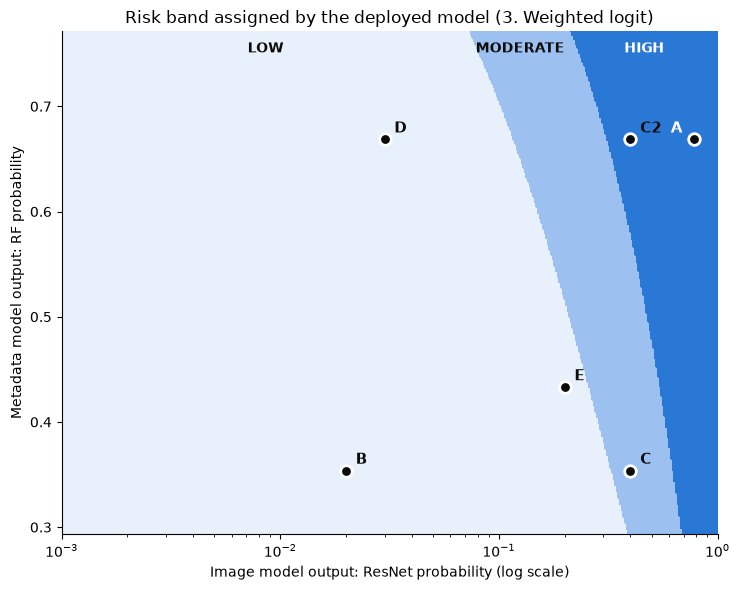

In [22]:
from matplotlib.colors import ListedColormap

g_img = np.logspace(-3, np.log10(0.999), 400)      # log-spaced to match the log x-axis
rf_lo, rf_hi = fusion_df["rf_probability"].min(), fusion_df["rf_probability"].max()
pad = 0.03
g_meta = np.linspace(max(rf_lo - pad, 0), min(rf_hi + pad, 1), 400)   # the RF's observed range
GI, GM = np.meshgrid(g_img, g_meta)
grid = pd.DataFrame({"resnet_probability": GI.ravel(), "rf_probability": GM.ravel()})
_, _, _, band = primary.score(grid)
Z = pd.Series(band).map({"LOW": 0, "MODERATE": 1, "HIGH": 2}).to_numpy().reshape(GI.shape)

band_cols = ["#e8f0fb", "#9cc0ef", "#2a78d6"]           # one hue, light -> dark = low -> high risk
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.contourf(GI, GM, Z, levels=[-0.5, 0.5, 1.5, 2.5], colors=band_cols)
top_row = Z[-1]                                        # band along the top edge (RF ~ 1)
for code_, lab, col in [(0, "LOW", "#0b0b0b"), (1, "MODERATE", "#0b0b0b"), (2, "HIGH", "white")]:
    xs = g_img[top_row == code_]
    if xs.size:                                        # label at the band's centre in log space
        ax.text(np.sqrt(xs.min() * xs.max()), g_meta[-1] - 0.02, lab, ha="center", fontsize=10, color=col, weight="bold")
pts = mock_cases.dropna(subset=["rf_probability"])
ax.scatter(pts["resnet_probability"], pts["rf_probability"], s=70, c="#0b0b0b",
           edgecolors="white", linewidths=2, zorder=3)
for cid, r in pts.iterrows():
    right_edge = r.resnet_probability > 0.6           # keep labels inside the plot
    ax.annotate(cid, (r.resnet_probability, r.rf_probability), fontsize=11, weight="bold",
                xytext=(-8 if right_edge else 7, 5), textcoords="offset points",
                ha="right" if right_edge else "left",
                color="white" if right_edge or r.resnet_probability > 0.4 else "#0b0b0b")
ax.set_xscale("log")
ax.set_xlim(0.001, 1.0); ax.set_ylim(g_meta[0], g_meta[-1])
ax.set_xlabel("Image model output: ResNet probability (log scale)")
ax.set_ylabel("Metadata model output: RF probability")
ax.set_title(f"Risk band assigned by the deployed model ({chosen})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 8d. Reading the deployment results
The cell below prints the facts the interpretation rests on, so the text never goes stale when a base
model is retrained. Read it with three questions in mind:
* **Who drives the decision?** The learned weight w (and the LR-stacking coefficients) say how much
  the fusion trusts the image versus the metadata.
* **Can metadata change a decision on its own?** Compare C with C2 (same image, different profile)
  and look at D (reassuring image, high-risk profile).
* **What does missing metadata cost?** Compare F with the same image scored with a typical profile.

Limits: the calibration and thresholds come from 25 melanomas in 85 patients, so they carry wide
uncertainty (section 3a). This demonstration is educational and not validated for clinical use.

In [23]:
w = final_models["3. Weighted logit"].w_
co = final_models["4. LR stacking"].coefs_
print(f"Deployed model: {chosen}")
print(f"Weighted logit: w = {w:.2f} -> {w:.0%} image, {1 - w:.0%} metadata (log-odds scale)")
print(f"LR stacking:    b_image = {co['b_cnn']:.2f}, c_meta = {co['c_rf']:.2f} "
      f"-> image share {co['b_cnn'] / (co['b_cnn'] + co['c_rf']):.0%}")

r = report
print(f"\nSame image (ResNet {r.loc['C', 'resnet_probability']:.2f}), different profile:")
print(f"  C  low-risk profile  (RF {r.loc['C', 'rf_probability']:.2f}): {r.loc['C', 'melanoma_prob']:.1%} -> {r.loc['C', 'risk_band']}")
print(f"  C2 high-risk profile (RF {r.loc['C2', 'rf_probability']:.2f}): {r.loc['C2', 'melanoma_prob']:.1%} -> {r.loc['C2', 'risk_band']}")
print(f"Reassuring image, high-risk profile (D): {r.loc['D', 'melanoma_prob']:.1%} -> {r.loc['D', 'risk_band']}")

f_typ = assess(mock_cases.loc[["F"]].assign(rf_probability=RF_TYP))
print(f"\nCase F without metadata (CNN only): {r.loc['F', 'melanoma_prob']:.1%} -> {r.loc['F', 'risk_band']}")
print(f"Case F if the profile were typical : {f_typ['melanoma_prob'].iloc[0]:.1%} -> {f_typ['risk_band'].iloc[0]}")

Deployed model: 3. Weighted logit
Weighted logit: w = 0.50 -> 50% image, 50% metadata (log-odds scale)
LR stacking:    b_image = 0.91, c_meta = 0.91 -> image share 50%

Same image (ResNet 0.40), different profile:
  C  low-risk profile  (RF 0.35): 3.3% -> MODERATE
  C2 high-risk profile (RF 0.67): 10.4% -> HIGH
Reassuring image, high-risk profile (D): 0.7% -> LOW

Case F without metadata (CNN only): 4.0% -> MODERATE
Case F if the profile were typical : 3.0% -> MODERATE
